# Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Fetch Solar & Wind FCST Generation

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"


# Period
today = pd.Timestamp.now(
    tz=f"Europe/{country_capital}"
).normalize()

yesterday=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=1)
)
last_week=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=7)
)

tomorrow =(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    + pd.Timedelta(days=1)
)

start=last_week
end=today


# ENTSOE Client
df = entsoe_client.query_wind_and_solar_forecast(
    country_code=country_code,
    start=last_week,
    end=today)

# EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-08-05 00:00:00+02:00 to 2026-08-11 23:45:00+02:00
Freq: 15min
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Solar         672 non-null    float64
 1   Wind Onshore  672 non-null    float64
dtypes: float64(2)
memory usage: 15.8 KB


In [4]:
df.head()

,Solar,Wind Onshore
2026-08-05 00:00:00+02:00,550.0,5966.0
2026-08-05 00:15:00+02:00,535.0,5831.0
2026-08-05 00:30:00+02:00,521.0,5698.0
2026-08-05 00:45:00+02:00,508.0,5568.0
2026-08-05 01:00:00+02:00,491.0,5431.0


In [5]:
df.columns

Index(['Solar', 'Wind Onshore'], dtype='str')

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Solar,672.0,10455.79,10244.28,189.0,489.00,6272.5,21685.75,27351.0
Wind Onshore,672.0,3664.45,1938.21,600.0,1913.75,3505.0,5175.25,8121.0


In [7]:
# Check that timestamps are unique
assert df.index.is_unique

# Check that timestamps are sorted
assert df.index.is_monotonic_increasing

In [8]:
df_mwh = df.copy()

for col in df_mwh.columns:
    df_mwh[col]*= 0.25

df_mwh.head()

,Solar,Wind Onshore
2026-08-05 00:00:00+02:00,137.50,1491.50
2026-08-05 00:15:00+02:00,133.75,1457.75
2026-08-05 00:30:00+02:00,130.25,1424.50
2026-08-05 00:45:00+02:00,127.00,1392.00
2026-08-05 01:00:00+02:00,122.75,1357.75


In [9]:
df_mwh.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Solar,672.0,2613.95,2561.07,47.25,122.25,1568.12,5421.44,6837.75
Wind Onshore,672.0,916.11,484.55,150.00,478.44,876.25,1293.81,2030.25


In [10]:
generation_per_day = pd.pivot_table(
    df_mwh,
    values=["Solar", "Wind Onshore"],
    index=df_mwh.index.date,
    aggfunc="sum"
) 

print(generation_per_day.round(2))

                Solar  Wind Onshore
2026-08-05  261172.25      96456.50
2026-08-06  251966.50     103298.75
2026-08-07  254486.50      73480.25
2026-08-08  233616.75      86176.25
2026-08-09  239182.75     103602.00
2026-08-10  239714.75      91256.00
2026-08-11  276432.75      61357.50


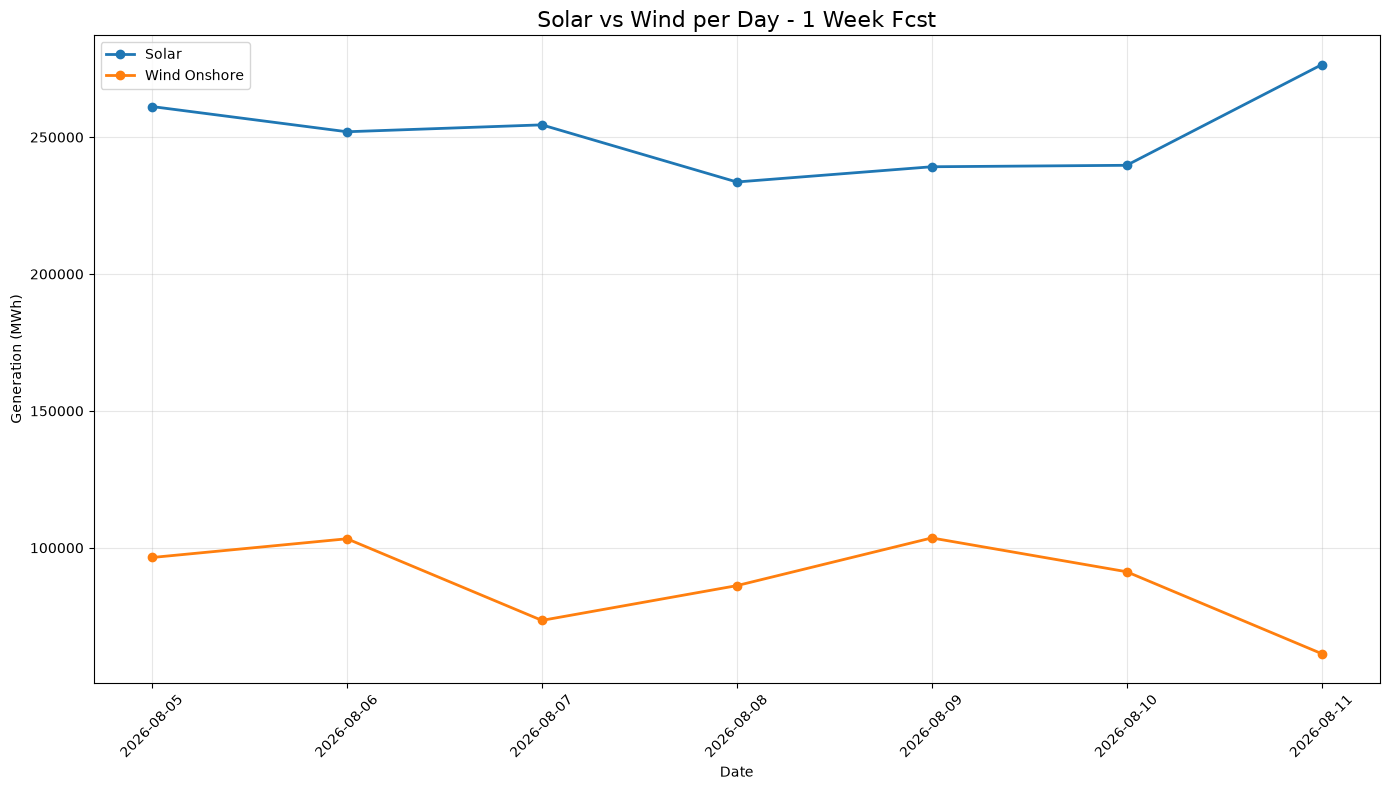

In [11]:
# Plot \Solar vs Wind per Day - 1 Week Fcst/

fig, ax = plt.subplots(figsize=(14, 8))

for col in generation_per_day.columns:
    ax.plot(
        generation_per_day.index,
        generation_per_day[col],
        marker="o",
        linewidth=2,
        label=col
    )


plt.title("Solar vs Wind per Day - 1 Week Fcst", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Generation (MWh)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

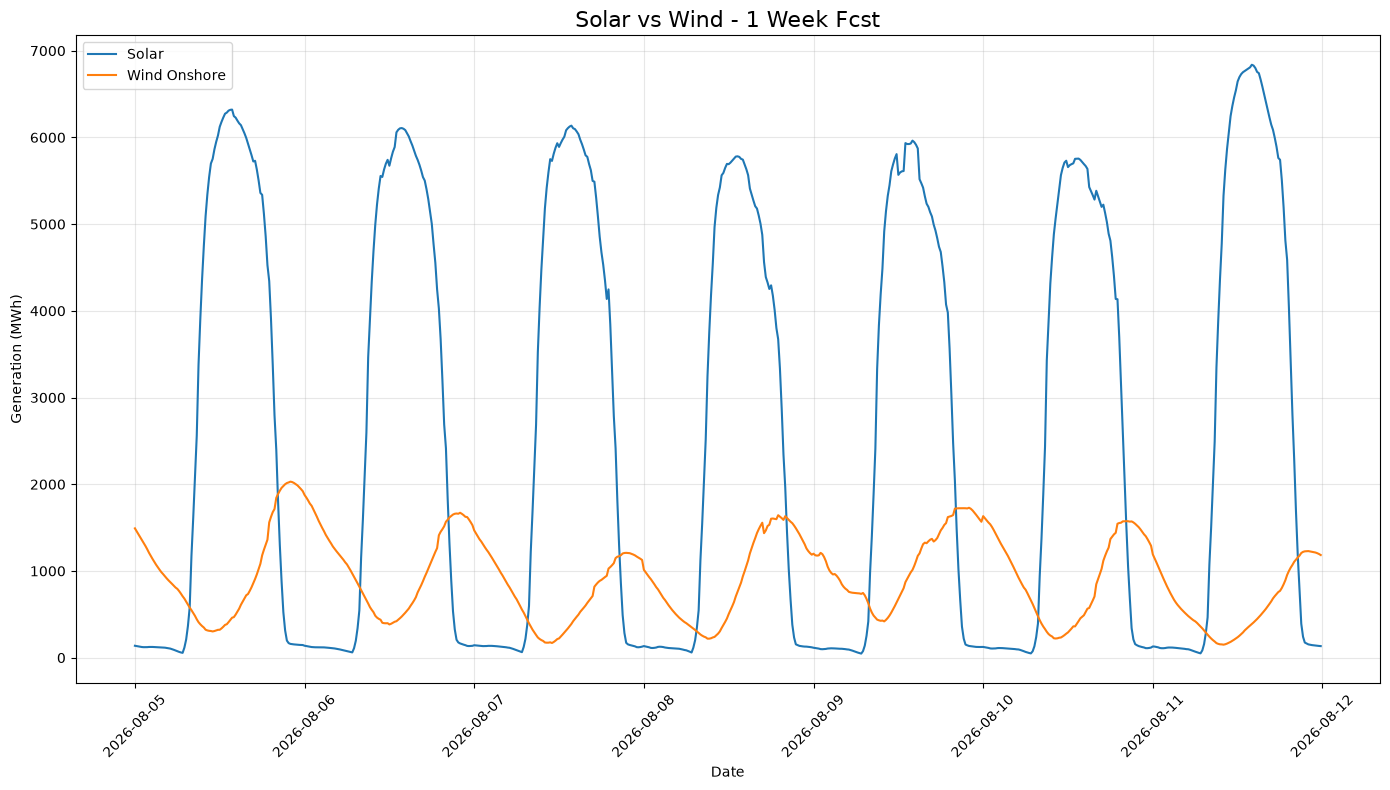

In [12]:
# Plot \Solar vs Wind - 1 Week Fcst/

fig, ax = plt.subplots(figsize=(14, 8))

for col in df_mwh.columns:
    ax.plot(
        df_mwh.index,
        df_mwh[col],
        linewidth=1.5,
        label=col
    )

plt.title("Solar vs Wind - 1 Week Fcst", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Generation (MWh)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()